In [2]:
import astropy
from astropy.table import Table, hstack
import astropy.units as u
from astropy.io import ascii
import astropy.constants as con
from astropy.constants import alpha, c, e, hbar, m_e, m_p, sigma_sb
from astropy.utils.data import get_pkg_data_filename
from astropy.cosmology import WMAP9 as cosmo

import numpy as np
import matplotlib.pyplot as plt

from Validator import (
    validate_array,
    validate_physical_type,
    validate_scalar,
)
#from .model_utils import memoize
from Utils import trapz_loglog,trapz_numba,simpson_uniform
from Utils import adaptive_shells_simple

import Models
import RadiativeCopy as Radiative

import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.animation import FuncAnimation, PillowWriter


from scipy.integrate import quad
import time
from datetime import datetime
from joblib import Parallel, delayed
from tqdm import tqdm
import os

In [10]:

m_e = con.m_e.cgs.value
c = con.c.cgs.value
mec2_eV = (con.m_e * con.c ** 2.).to('eV').value
h = con.h.cgs.value
el = con.e.gauss.value
erg_to_eV = 624150912588.3258  # conversion from erg to eV
sigma_T = con.sigma_T.cgs.value
mpc2 = (con.m_p * con.c ** 2.).to('eV')
mpc2_erg = mpc2.to('erg').value

In [8]:
def E_theta_gaussian(theta,thetaend=20*u.deg,thetacore=5*u.deg,Eiso_zero=1e51):
    thetaw_deg=thetaend
    thetacore=thetacore
    Eiso_zero=Eiso_zero

    theta_rad = np.deg2rad(theta.value)
    thetacore_rad = np.deg2rad(thetacore.value)
    thetaw_rad = np.deg2rad(thetaw_deg.value)

    E = np.zeros_like(theta_rad)
    inside = theta_rad <= thetaw_rad
    E[inside] = Eiso_zero * np.exp(-(theta_rad[inside]**2) / (2 * thetacore_rad**2))
    E = np.maximum(E, 1e-40) #floor to avoid numerical issues
    return E 

In [39]:
def doppler_factor(Gamma, theta,theta_obs, phi):
    
    try:
        theta = theta.to("deg").value
        theta_obs = theta_obs.to("deg").value
        phi = phi.to("deg").value
    except AttributeError:
        pass  # already floats in deg

    # Convert to radians
    theta = np.deg2rad(theta)
    theta_obs = np.deg2rad(theta_obs)
    phi = np.deg2rad(phi)
    
    cos_psi = np.cos(theta) * np.cos(theta_obs) + np.sin(theta) * np.sin(theta_obs) * np.cos(phi)
    beta = np.sqrt(1.0 - 1.0 / Gamma**2)
    return 1.0 / (Gamma * (1.0 - beta * cos_psi ))

In [36]:
theta_obs=0.0*u.deg

def compute_dynamics(avtime, theta,energy_profile='gaussian',density=0.01):
    """Calcola Lorentz factor, raggio e energia"""
    theta = np.atleast_1d(theta)

    if energy_profile=='gaussian':
        Energy = E_theta_gaussian(theta)
    else:
        raise ValueError(f"Unknown energy profile: {energy_profile}")  
        

    Gamma = (3.0 * Energy / (8.0 * np.pi * 512.0 * density * mpc2_erg * (c * avtime) ** 3.0)) ** 0.125
    Gamma = np.maximum(Gamma, 1.0)
    R = 8. * c * avtime * Gamma ** 2

    return Gamma, R, Energy

In [43]:
def plot_doppler_3D(plane=True,circle=True,surface=True,pixels=300,crop=True,Save=None,Path=None,Name="doppler 3D"):
    
    theta_limits=[0,2,4,6,8,10,12,14,16,18,20]
    avtime=200

    if crop==True:
        theta_vals = np.linspace((max(0,theta_obs.value-5)),theta_obs.value+5, pixels)*u.deg
    else:
        theta_vals = np.linspace((max(0,theta_obs.value-20)),theta_obs.value+20, pixels)*u.deg
    
    print("Theta range:",np.min(theta_vals),np.max(theta_vals))

    phi_vals   = np.linspace(-180, 180,pixels)*u.deg # φ da 0° a 360°
    Theta, Phi = np.meshgrid(theta_vals, phi_vals, indexing="ij")

    Gamma, R, Energy=compute_dynamics(avtime=avtime, theta=Theta)
    print(Gamma)
    doppler_shells= doppler_factor(Gamma,Theta, theta_obs, Phi)


    ###################################################################################


    ###################################################################################


    if plane==True:
    
        #---------------------------------- PLOT 2D ----------------------------------------------

        fig, ax = plt.subplots(1,1, figsize=(10,7), sharex=False, sharey=False)

        #pcm1 = axes[0].pcolormesh(Phi, Theta, doppler_gamma_fix, shading='auto', cmap='viridis')
        pcm1 = ax.pcolormesh(Phi, Theta, doppler_shells, shading='auto', cmap='viridis')
        ax.set_title(f"Doppler Gamma(θ) with (θ_obs={theta_obs}°) and Time={avtime}s")
        ax.set_xlabel(r"$\phi$ [deg]")
        ax.set_ylabel(r"$\theta$ [deg]")

        #axes[0].set_ylim(4,6)
        #axes[0].set_xlim(-50,50)

        ax.grid(True, which="both", linestyle="--", alpha=0.6)
        ax.axhline(y=theta_obs.value, color="red", linestyle="--", lw=2, label=f'θ_obs = {theta_obs}°')
        ax.legend(loc="upper right")
        fig.colorbar(pcm1, ax=ax,label=r"$\delta(\theta,\phi)$")
        #--------------------------------------------------------------------------------------------------------

        """pcm2 = axes[1].pcolormesh(Phi, Theta, doppler_gamma_theta, shading='auto', cmap='plasma')
        axes[1].set_title(f"Doppler Gamma(θ) with (θ_obs={theta_obs}°) and Time={self.avtime}s")
        axes[1].set_xlabel(r"$\phi$ [deg]")
        axes[1].set_ylabel(r"$\theta$ [deg]")
        #axes[1].set_ylim(2,8)
        #axes[1].set_xlim(-50,50)

        axes[1].grid(True, which="both", linestyle="--", alpha=0.6)
        axes[1].axhline(y=theta_obs.value, color="red", linestyle="--", lw=2, label=f'θ_obs = {theta_obs}°')
        axes[1].legend(loc="upper right")
        fig.colorbar(pcm2, ax=axes[1],label=r"$\delta(\theta,\phi)$")"""

        plt.tight_layout()


        
        plt.show()

    if circle==True:
        Phi_rad = np.radians(Phi)

        # --- Figure con due pannelli polari ---
        fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'polar'}, figsize=(10,7))

        # Primo plot: Gamma fisso
        pcm1 = ax.pcolormesh(Phi_rad, Theta,  doppler_shells, shading='auto', cmap='viridis')

        ax.set_title(f"Doppler Gamma(θ) with ( θ_obs={theta_obs}°) and Time={avtime}s", va='bottom')
        #axes[0].set_ylim(4, 6)  
        ax.grid(True, which="both", linestyle="--", alpha=0.6)

        ax.plot(np.linspace(0, 2*np.pi, 200),np.full(200, theta_obs), 'r:', lw=2, label=f'θ_obs = {theta_obs}°')
        ax.legend(loc="upper right")
        ax.set_rlabel_position(+20)

        #axes[0].set_rticks([0, 10, 20,30,40,50,60,70,80,90])  # solo queste tacche radiali
        #axes[0].tick_params(axis='y', colors='white', labelsize=12, labelrotation=0)

        fig.colorbar(pcm1, ax=ax, pad=0.1, label=r"$\delta(\theta,\phi)$")

        # Secondo plot: Gamma(theta)
        """pcm2 = axes[1].pcolormesh(Phi_rad, Theta, doppler_gamma_theta, shading='auto', cmap='plasma')
        axes[1].set_title(f"Doppler Gamma(θ) with ( θ_obs={theta_obs}°) and Time={self.avtime}s", va='bottom')
        #axes[1].set_ylim(2, 8) 
        axes[1].grid(True, which="both", linestyle="--", alpha=0.6)

        axes[1].plot(np.linspace(0, 2*np.pi, 200),np.full(200, theta_obs), 'r:', lw=2, label=f'θ_obs = {theta_obs}°')
        axes[1].legend(loc="upper right")
        fig.colorbar(pcm2, ax=axes[1], pad=0.1, label=r"$\delta(\theta,\phi)$")"""
        plt.tight_layout()



    if surface==True:
        # Figure con due subplot 3D
        fig = plt.figure(figsize=(18,7))

        # --- Primo subplot: Gamma fix ---
        ax1 = fig.add_subplot(1, 2, 1, projection='3d')

        surf1 = ax1.plot_surface(Phi, Theta[::-1], doppler_shells,cmap='viridis', edgecolor='none')
        ax1.set_title(f"Doppler Gamma(θ) with ( θ_obs={theta_obs}°) and Time={avtime}s")

        ax1.set_xlabel(r"$\phi$ [deg]")
        ax1.set_ylabel(r"$\theta$ [deg]")
        ax1.set_zlabel(r"$\delta(\theta,\phi)$")
        #ax1.set_xlim(0, 360)
        #ax1.set_ylim(8, 12)
        fig.colorbar(surf1, ax=ax1, shrink=0.6, label=r"$\delta$")

        # --- Secondo subplot: Gamma(theta) ---
        """ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        surf2 = ax2.plot_surface(Phi, Theta[::-1], doppler_gamma_theta,cmap='plasma', edgecolor='none')

        ax2.set_title(f"Doppler Gamma(θ) with ( θ_obs={theta_obs}°) and Time={self.avtime}s")
        ax2.set_xlabel(r"$\phi$ [deg]")
        ax2.set_ylabel(r"$\theta$ [deg]")
        ax2.set_zlabel(r"$\delta(\theta,\phi)$")
        #ax2.set_xlim(0, 360)
        #ax2.set_ylim(3, 10)
        fig.colorbar(surf2, ax=ax2, shrink=0.6, label=r"$\delta$")"""


        plt.show()
    
    else:
        raise ValueError("At least one of 'plane', 'circle', or 'surface' must be True.")

Theta range: 0.0 deg 5.0 deg
[[53.9669059  53.9669059  53.9669059  ... 53.9669059  53.9669059
  53.9669059 ]
 [53.96686817 53.96686817 53.96686817 ... 53.96686817 53.96686817
  53.96686817]
 [53.96675499 53.96675499 53.96675499 ... 53.96675499 53.96675499
  53.96675499]
 ...
 [50.73948118 50.73948118 50.73948118 ... 50.73948118 50.73948118
  50.73948118]
 [50.71837983 50.71837983 50.71837983 ... 50.71837983 50.71837983
  50.71837983]
 [50.69721636 50.69721636 50.69721636 ... 50.69721636 50.69721636
  50.69721636]]


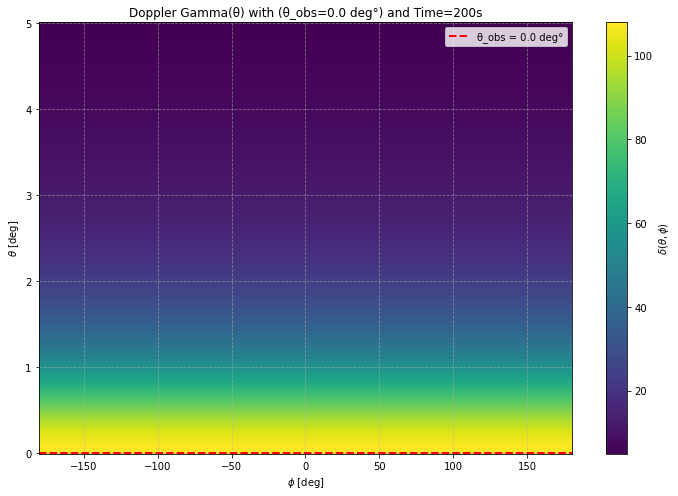

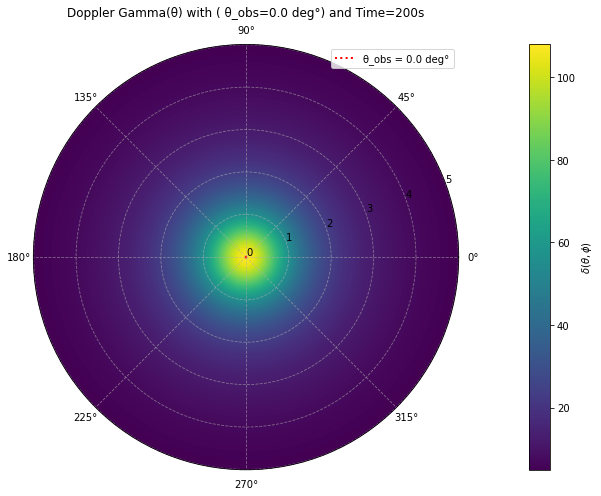

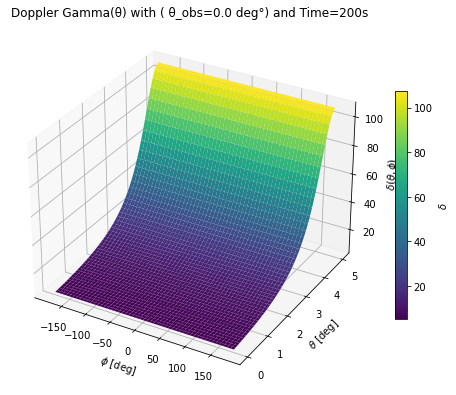

In [44]:
plot_doppler_3D(plane=True,circle=True,surface=True,pixels=300,crop=True,Save=None,Path=None,Name="doppler 3D")

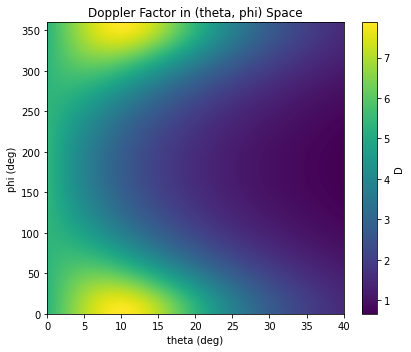

In [32]:
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------
# Doppler factor function
# ----------------------------
def doppler_factor(Gamma, theta, theta_obs, phi):
    """
    Gamma: bulk Lorentz factor
    theta: grid of polar angles in degrees
    theta_obs: observer angle (deg)
    phi: grid of azimuth angles in degrees
    """
    theta_rad = np.deg2rad(theta)
    theta_obs_rad = np.deg2rad(theta_obs)
    phi_rad = np.deg2rad(phi)

    cos_psi = (
        np.cos(theta_rad) * np.cos(theta_obs_rad)
        + np.sin(theta_rad) * np.sin(theta_obs_rad) * np.cos(phi_rad)
    )

    beta = np.sqrt(1.0 - 1.0 / Gamma**2)
    return 1.0 / (Gamma * (1.0 - beta * cos_psi))


# ----------------------------
# Example: compute Doppler map
# ----------------------------
Gamma = 4
theta_obs = 10  # degrees

# angle grids
theta_vals = np.linspace(0, 40, 200)   # polar angle θ
phi_vals = np.linspace(0, 360, 200)    # azimuth φ

TH, PH = np.meshgrid(theta_vals, phi_vals)

# compute Doppler factor
D = doppler_factor(Gamma, TH, theta_obs, PH)


# ----------------------------
# Plot (heatmap)
# ----------------------------
plt.figure(figsize=(6,5))
plt.imshow(
    D,
    extent=[theta_vals.min(), theta_vals.max(), phi_vals.min(), phi_vals.max()],
    origin="lower",
    aspect="auto",
)
plt.xlabel("theta (deg)")
plt.ylabel("phi (deg)")
plt.title("Doppler Factor in (theta, phi) Space")
plt.colorbar(label="D")
plt.tight_layout()
plt.show()
